In [1]:
import os
import sys
import numpy as np
import pandas as pd
import scipy
import scanpy as sc
import logging
import traceback
from anndata import AnnData, read_h5ad

from __future__ import annotations
import liana as li
from liana.method import singlecellsignalr, connectome, cellphonedb, natmi, logfc, cellchat, geometric_mean
from liana.plotting._common import _prep_liana_res, _check_var, _get_top_n, _filter_by, _invert_scores
from liana._docs import d
from liana._constants import Keys as K, DefaultValues as V

import multiprocessing
import plotnine as p9

from plotnine import ggplot, geom_point, aes, \
    facet_grid, labs, theme_bw, theme, element_text, element_rect, scale_size_continuous, scale_color_cmap


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:

def _filter_by2(liana_res, filter_fun):
    if filter_fun is not None:
        msk = liana_res.apply(filter_fun, axis=1).astype(bool)
        relevant_interactions = np.unique(liana_res[msk].interaction)
        liana_res = liana_res[np.isin(liana_res['interaction'], relevant_interactions)]

    return liana_res
@d.dedent
def liana_dotplot_dk(adata: anndata.AnnData = None,
            uns_key = K.uns_key,
            liana_res: pandas.DataFrame = None,
            colour: str = None,
            size: str = None,
            source_labels: list = None,
            target_labels: list = None,
            top_n: int = None,
            orderby: str | None = None,
            orderby_ascending: bool | None = None,
            orderby_absolute: bool = False,
            filter_fun: callable = None,
            ligand_complex: str | None = None,
            receptor_complex: str | None = None,
            inverse_colour: bool = False,
            inverse_size: bool = False,
            cmap: str = V.cmap,
            size_range: tuple = (2, 9),
            figure_size: tuple = (8, 6),
            color_limits: tuple = (0,12),
            size_limits: tuple = (0,2),
            return_fig=V.return_fig
            ) -> ggplot:
    """
    Dotplot interactions by source and target cells

    Parameters
    ----------
    %(adata)s
    %(uns_key)s
    %(liana_res)s
    %(colour)s
    %(size)s
    %(source_labels)s
    %(target_labels)s
    %(top_n)s
    %(orderby)s
    %(orderby_ascending)s
    %(orderby_absolute)s
    %(filter_fun)s
    %(ligand_complex)s
    %(receptor_complex)s
    %(inverse_colour)s
    %(inverse_size)s
    %(cmap)s
    %(size_range)s
    %(figure_size)s

    Returns
    -------
    A `plotnine.ggplot` instance

    """
    liana_res = _prep_liana_res(adata=adata,
                                liana_res=liana_res,
                                source_labels=source_labels,
                                target_labels=target_labels,
                                ligand_complex = ligand_complex,
                                receptor_complex = receptor_complex,
                                uns_key=uns_key
                                )
    
    color_var = colour
    size_var= size
    _check_var(liana_res, var=colour, var_name='colour')
    _check_var(liana_res, var=size, var_name='size')

    liana_res = _filter_by2(liana_res, filter_fun)
    liana_res = _get_top_n(liana_res, top_n, orderby, orderby_ascending, orderby_absolute)

    # inverse sc if needed
    if inverse_colour:
        liana_res[colour] = _invert_scores(liana_res[colour])
    if inverse_size:
        liana_res[size] = _invert_scores(liana_res[size])

    # print(liana_res[size])
    # print(liana_res[colour])
    # generate plot
    # generate plot
    p = (ggplot(liana_res, aes(x='target', y='interaction', colour=color_var, size=size_var))
         + geom_point()
         + facet_grid('~source')
         + scale_size_continuous(range=size_range,minor_breaks=1,limits=size_limits)
         + scale_color_cmap(cmap, limits=color_limits)
         + labs(
                #color=str.capitalize(colour),
                #size=[None if x == 0 else x for x in size],
                y="Interactions (Ligand -> Receptor)",
                x="Target",
                title="Source")
         + theme_bw()
         + theme(legend_text=element_text(size=14),
                 strip_background=element_rect(fill="white"),
                 strip_text=element_text(size=15, colour="black"),
                 axis_text_y=element_text(size=10, colour="black"),
                 axis_title_y=element_text(colour="#808080", face="bold", size=15),
                 axis_text_x=element_text(size=11, face="bold", angle=90),
                 figure_size=figure_size,
                 plot_title=element_text(vjust=0, hjust=0.5, face="bold",
                                         colour="#808080", size=15)
                 )
         )
    
    if return_fig:
        return p

    p.draw()




In [3]:
os.chdir('/Users/dimitrioskyriakis/Documents/Projects/ICH_project/')


In [4]:
import hdf5plugin

adata = sc.read_h5ad('results/2024_04_22_Immune_Metacells_combined_stored_counts.h5ad.ztsd')

In [19]:
CCI_Df = adata.uns["liana_res"].copy()


In [20]:
CCI_Df

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,lr_probs,cellchat_pvals,specificity_rank,magnitude_rank
5453,MTC_456,NEUT,SPP1,CD44,3.893356,0.0,10.963501,1.541408,2.922254,0.071002,0.963017,0.254660,0.0,0.014529,4.732851e-11
4543,MTC_456,MONO,SPP1,CD44,3.851905,0.0,10.470951,1.480778,3.085206,0.067812,0.962190,0.240754,0.0,0.014529,1.277595e-09
7020,MTC_Prolif,NEUT,SPP1,CD44,3.238347,0.0,8.546183,1.223176,1.090093,0.055347,0.958317,0.210081,0.0,0.014529,3.573573e-08
2079,MONO,MTC_456,TIMP1,CD63,3.226183,0.0,10.210638,1.057699,2.301782,0.059812,0.961729,0.241517,0.0,0.014529,4.462969e-08
1657,MONO,MONO,TIMP1,CD63,3.177637,0.0,9.854238,1.020223,1.972345,0.057724,0.961070,0.235805,0.0,0.014529,7.988922e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8681,NEUT,T Cells,FAM3C,CLEC2D,0.550664,0.0,0.148263,0.709033,0.893010,0.040969,0.751747,0.000000,1.0,0.175529,1.000000e+00
8682,NEUT,T Cells,FAM3C,LAMP1,0.388410,1.0,0.097314,-0.223918,-0.302461,0.010106,0.710420,0.000000,1.0,1.000000,1.000000e+00
8683,NEUT,T Cells,FN1,CD44,0.627839,0.0,0.241114,0.800345,1.307460,0.038175,0.794308,0.000000,1.0,0.191153,1.000000e+00
8748,NEUT,T Cells,LGALS9,SLC1A5,0.478034,1.0,0.136978,-0.162075,-0.361115,0.011542,0.744286,0.000000,1.0,1.000000,1.000000e+00


In [21]:
start_with_cci = ("IL10", "IFN", "IL","C3","C5")  # Tuple of prefixes

IL10_subset_df = CCI_Df[
    CCI_Df["receptor_complex"].str.startswith(start_with_cci) | 
    CCI_Df["ligand_complex"].str.startswith(start_with_cci)
]

IL10_subset_df['CCI'] = IL10_subset_df['target'].astype(str)+':' + IL10_subset_df['ligand_complex'].astype(str) + '.' + IL10_subset_df['receptor_complex'].astype(str)
# Splitting the 'CCI' column into 'Target' and 'Ligand' columns based on the colon delimiter
IL10_subset_df[['Target', 'Ligand']] = IL10_subset_df['CCI'].str.split(':', expand=True)
# Extracting the 'Receptor' information from the 'Ligand' column
IL10_subset_df['Receptor'] = IL10_subset_df['Ligand'].str.split('.').str[1]
# Extracting the 'Ligand' information from the 'Ligand' column
IL10_subset_df['Ligand'] = IL10_subset_df['Ligand'].str.split('.').str[0]

/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_1950/2001382878.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_1950/2001382878.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/var/folders/_m/6gpcfwd11_56lg5zfmt0t7sr0000gn/T/ipykernel_1950/2001382878.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

In [22]:
CCI_Df

,source,target,ligand_complex,receptor_complex,lr_means,cellphone_pvals,expr_prod,scaled_weight,lr_logfc,spec_weight,lrscore,lr_probs,cellchat_pvals,specificity_rank,magnitude_rank
5453,MTC_456,NEUT,SPP1,CD44,3.893356,0.0,10.963501,1.541408,2.922254,0.071002,0.963017,0.254660,0.0,0.014529,4.732851e-11
4543,MTC_456,MONO,SPP1,CD44,3.851905,0.0,10.470951,1.480778,3.085206,0.067812,0.962190,0.240754,0.0,0.014529,1.277595e-09
7020,MTC_Prolif,NEUT,SPP1,CD44,3.238347,0.0,8.546183,1.223176,1.090093,0.055347,0.958317,0.210081,0.0,0.014529,3.573573e-08
2079,MONO,MTC_456,TIMP1,CD63,3.226183,0.0,10.210638,1.057699,2.301782,0.059812,0.961729,0.241517,0.0,0.014529,4.462969e-08
1657,MONO,MONO,TIMP1,CD63,3.177637,0.0,9.854238,1.020223,1.972345,0.057724,0.961070,0.235805,0.0,0.014529,7.988922e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8681,NEUT,T Cells,FAM3C,CLEC2D,0.550664,0.0,0.148263,0.709033,0.893010,0.040969,0.751747,0.000000,1.0,0.175529,1.000000e+00
8682,NEUT,T Cells,FAM3C,LAMP1,0.388410,1.0,0.097314,-0.223918,-0.302461,0.010106,0.710420,0.000000,1.0,1.000000,1.000000e+00
8683,NEUT,T Cells,FN1,CD44,0.627839,0.0,0.241114,0.800345,1.307460,0.038175,0.794308,0.000000,1.0,0.191153,1.000000e+00
8748,NEUT,T Cells,LGALS9,SLC1A5,0.478034,1.0,0.136978,-0.162075,-0.361115,0.011542,0.744286,0.000000,1.0,1.000000,1.000000e+00


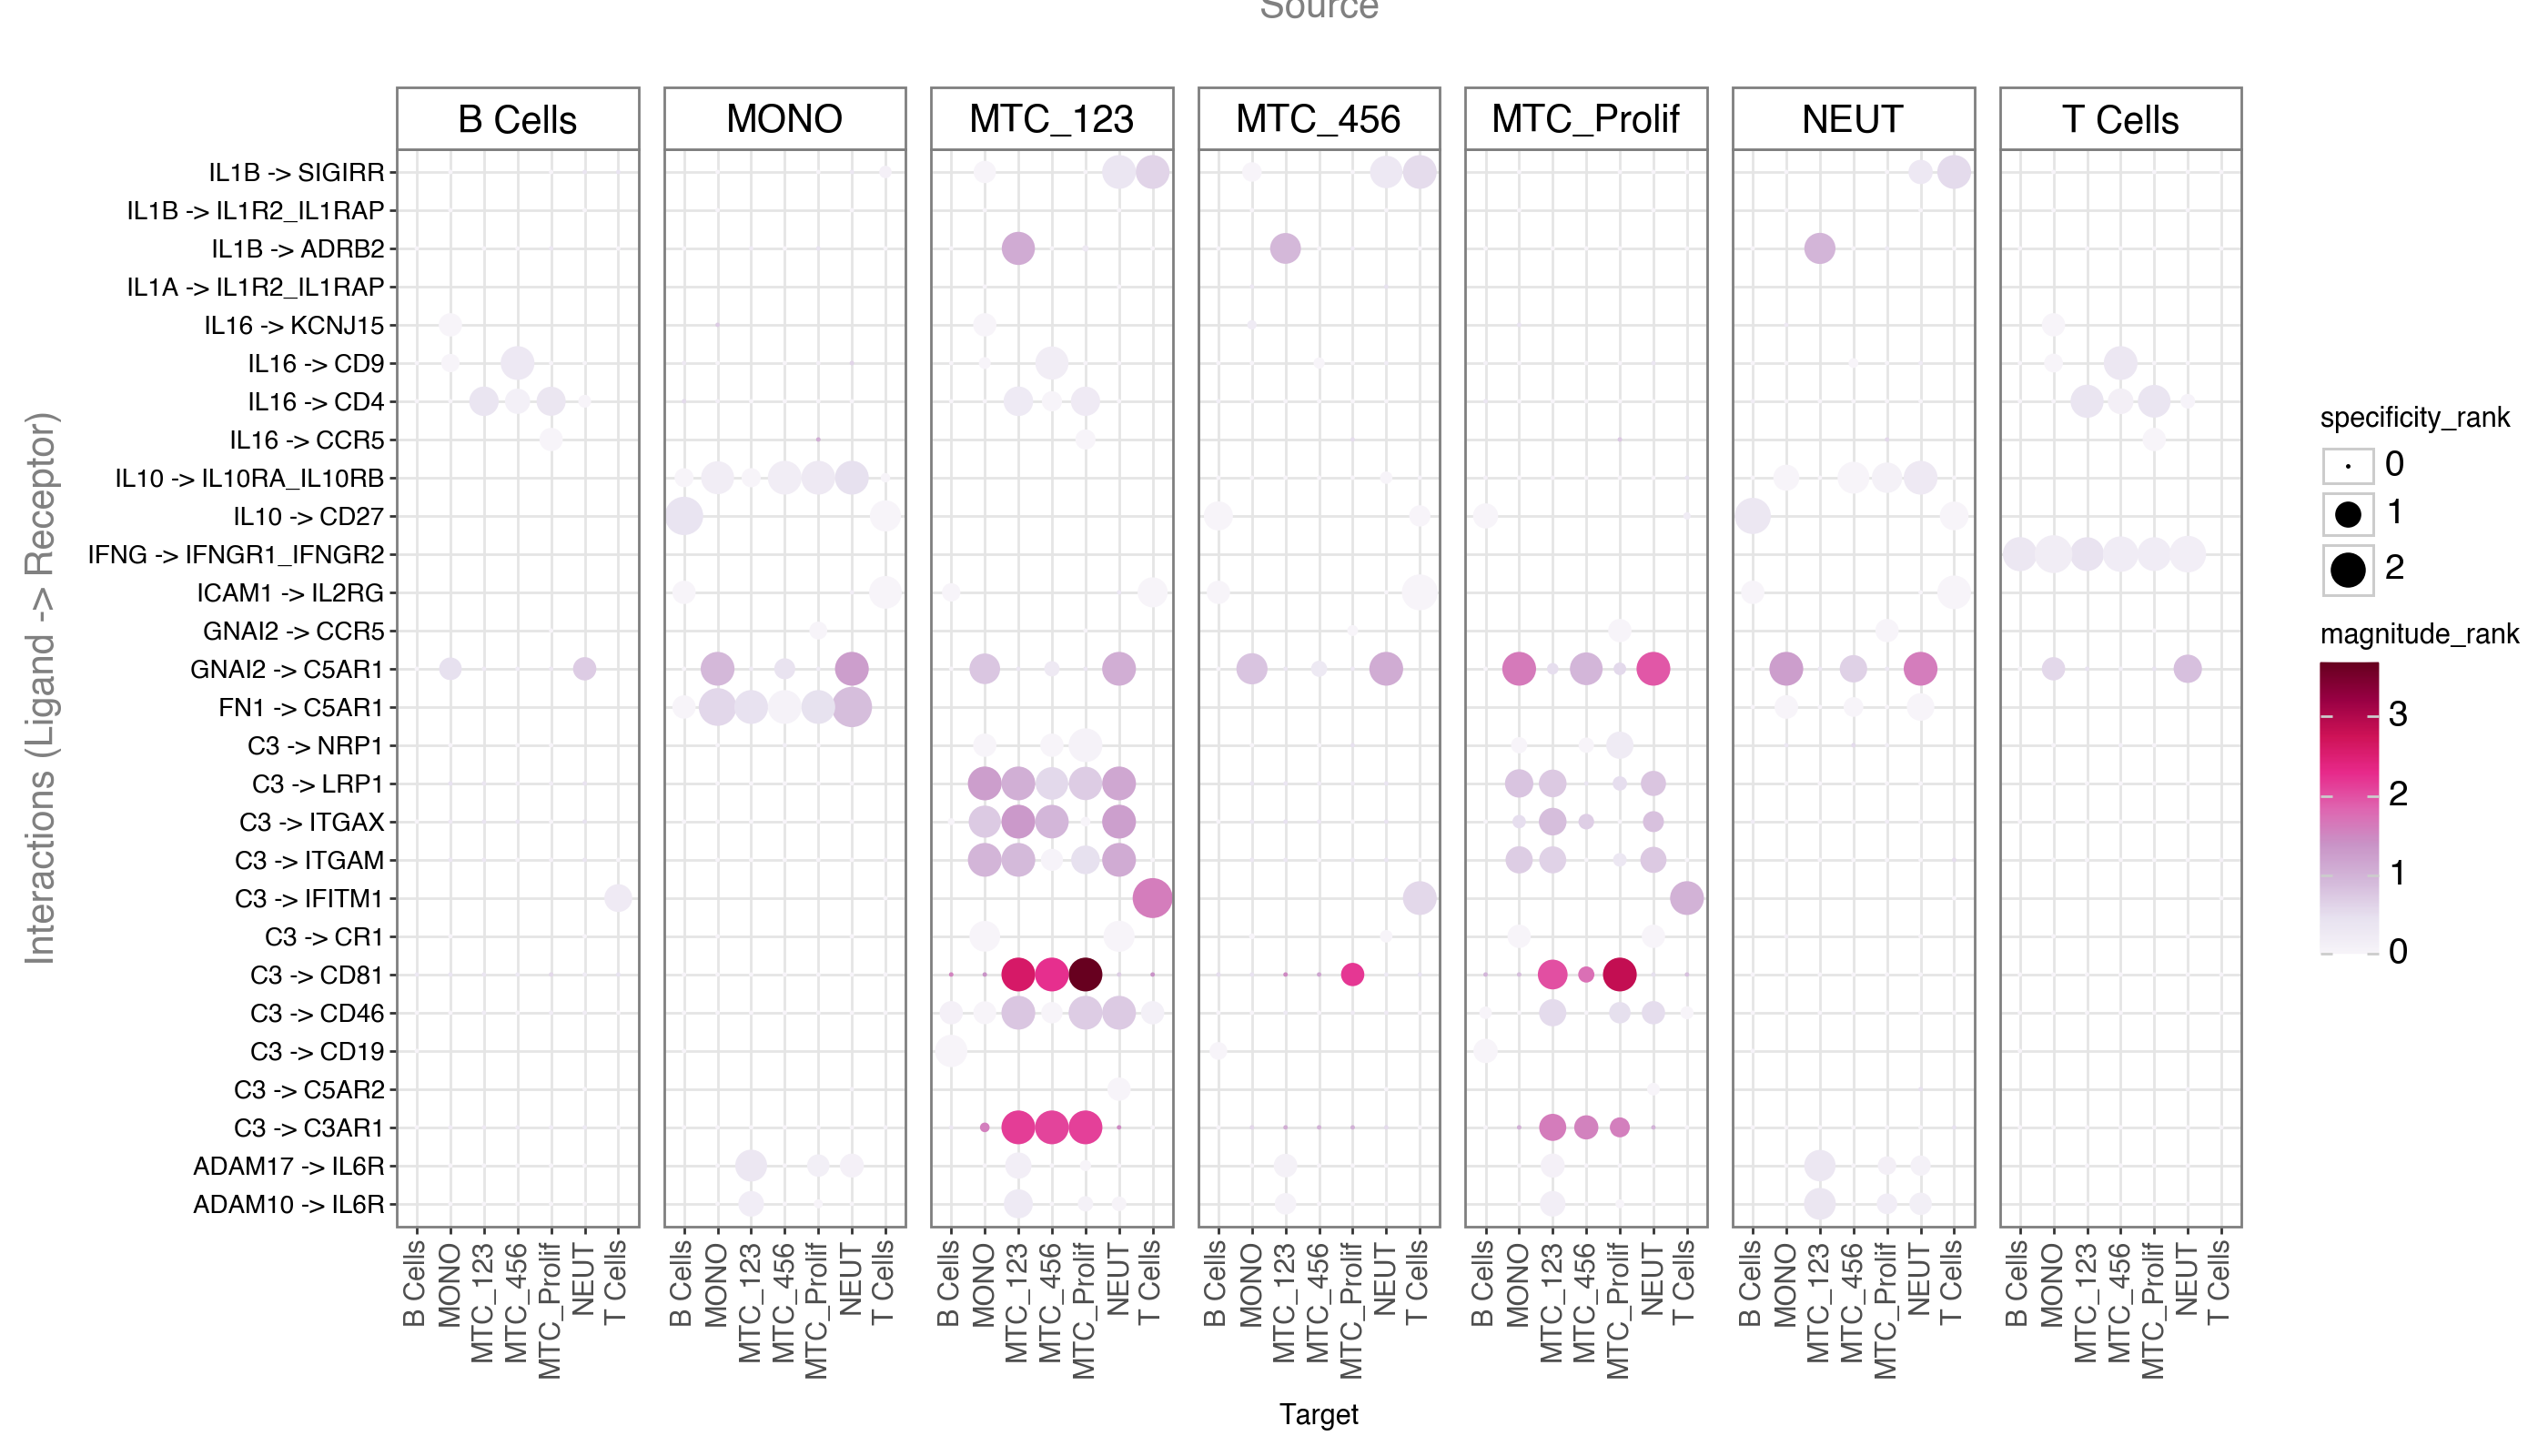

In [28]:
liana_dotplot_dk(adata = adata,
            colour='magnitude_rank',
            size='specificity_rank',
            inverse_size=True,
            inverse_colour=True,
            filter_fun=lambda x: x['ligand_complex'] in IL10_subset_df['Ligand'].tolist()  and 
                                 x['receptor_complex'] in IL10_subset_df['Receptor'].tolist(),
            orderby='magnitude_rank',
            orderby_ascending=True,
            figure_size=(14, 8),
            size_range= (0, 8),
            cmap = 'PuRd',
            color_limits= None,
            size_limits = None
            )